# Model Training for Parkinson's Disease Detection

Train RandomForest models on A/B/C feature setups and evaluate performance with permutation importance.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load A/B/C datasets and targets
final_dir = Path('../..') / 'data' / 'final'

# Load targets
y_train = pd.read_csv(final_dir / 'y_train.csv')['y_pd_binary']
y_test = pd.read_csv(final_dir / 'y_test.csv')['y_pd_binary']

# Load feature setups
setups = {}
for setup in ['a_sensor_demo', 'b_questionnaire_demo', 'c_all_modalities']:
    X_train = pd.read_csv(final_dir / f'X_train_{setup}_selected.csv')
    X_test = pd.read_csv(final_dir / f'X_test_{setup}_selected.csv')
    setups[setup] = {'X_train': X_train, 'X_test': X_test}

print("Loaded datasets:")
for setup, data in setups.items():
    print(f"{setup}: train {data['X_train'].shape}, test {data['X_test'].shape}")
print(f"Targets: train {y_train.shape}, test {y_test.shape}")

Loaded datasets:
a_sensor_demo: train (375, 25), test (94, 25)
b_questionnaire_demo: train (375, 25), test (94, 25)
c_all_modalities: train (375, 25), test (94, 25)
Targets: train (375,), test (94,)


In [3]:
# Hyperparameter tuning for RandomForest
param_distributions = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

best_params = {}
search_results_raw = {}
for setup, data in setups.items():
    print(f"Tuning hyperparameters for {setup}...")
    rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

    search = RandomizedSearchCV(
        rf_base,
        param_distributions,
        n_iter=20,  # Limit iterations for speed
        cv=5,  # 5-fold CV for tuning
        scoring='roc_auc',
        random_state=42,
        n_jobs=-1
    )

    search.fit(data['X_train'], y_train)
    best_params[setup] = search.best_params_
    search_results_raw[setup] = search
    print(f"Best params for {setup}: {search.best_params_}")
    print(f"Best CV score: {search.best_score_:.3f}")
    print()

Tuning hyperparameters for a_sensor_demo...
Best params for a_sensor_demo: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None}
Best CV score: 0.661

Tuning hyperparameters for b_questionnaire_demo...
Best params for b_questionnaire_demo: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None}
Best CV score: 0.840

Tuning hyperparameters for c_all_modalities...
Best params for c_all_modalities: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Best CV score: 0.844



In [4]:
# Train RandomForest models with tuned hyperparameters
models = {}
for setup, data in setups.items():
    params = best_params[setup]
    rf = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(data['X_train'], y_train)
    models[setup] = rf
    print(f"Trained tuned RandomForest for {setup}")
    print(f"Parameters: {params}")
    print()

Trained tuned RandomForest for a_sensor_demo
Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None}

Trained tuned RandomForest for b_questionnaire_demo
Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None}

Trained tuned RandomForest for c_all_modalities
Parameters: {'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}




A_SENSOR_DEMO Results:
Accuracy: 0.681
ROC-AUC: 0.753
F1: 0.741


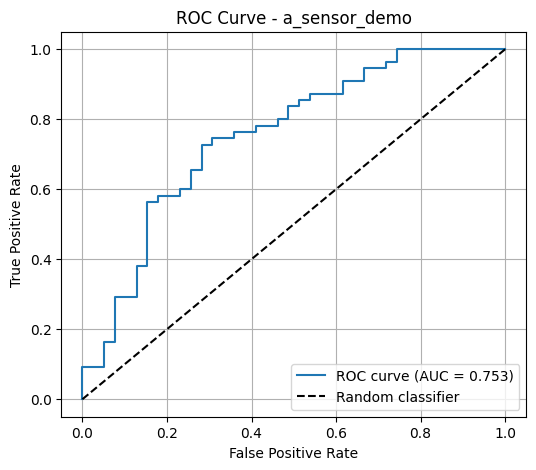


B_QUESTIONNAIRE_DEMO Results:
Accuracy: 0.787
ROC-AUC: 0.825
F1: 0.831


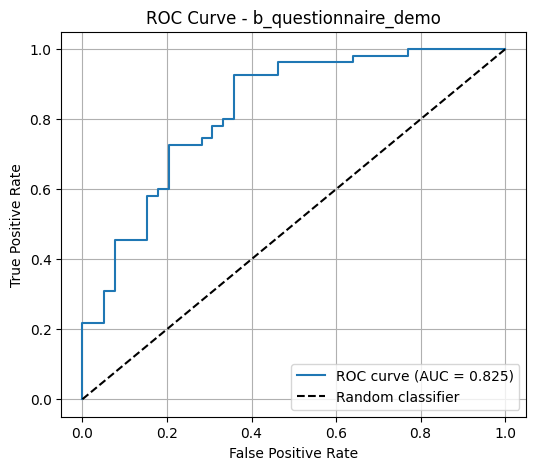


C_ALL_MODALITIES Results:
Accuracy: 0.809
ROC-AUC: 0.844
F1: 0.842


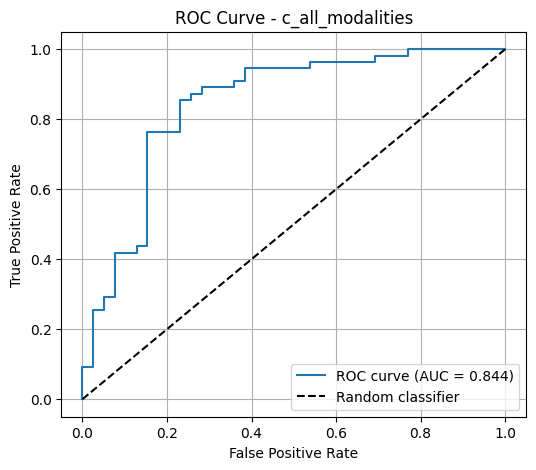

In [5]:
# Evaluate models on test set
results = {}
for setup, model in models.items():
    X_test = setups[setup]['X_test']
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    results[setup] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'classification_report': classification_report(y_test, y_pred, output_dict=True)
    }
    
    print(f"\n{setup.upper()} Results:")
    print(f"Accuracy: {results[setup]['accuracy']:.3f}")
    print(f"ROC-AUC: {results[setup]['roc_auc']:.3f}")
    print(f"F1: {results[setup]['f1']:.3f}")

    # Plot ROC curve for the current setup
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {results[setup]["roc_auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {setup}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

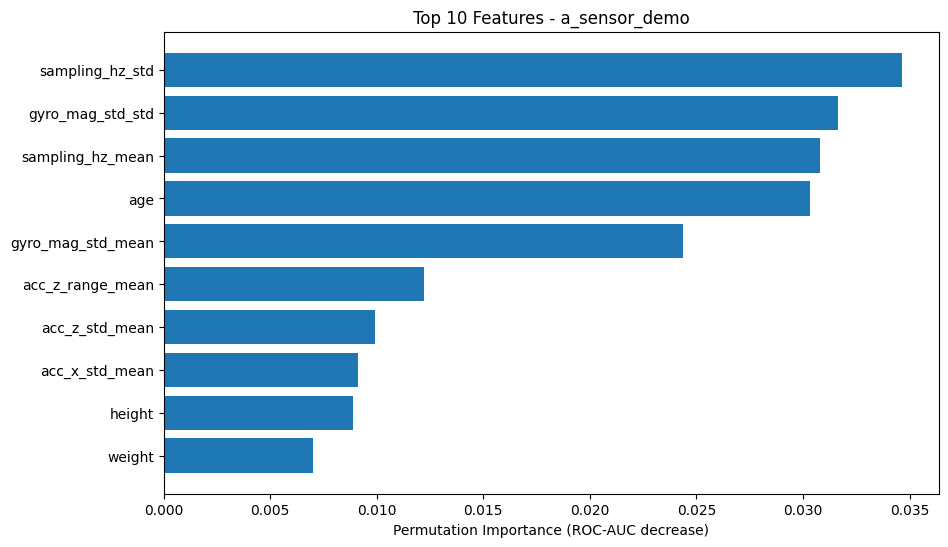


Top 5 features for a_sensor_demo:
             feature  importance_mean  importance_std
0    sampling_hz_std         0.034639        0.025319
4   gyro_mag_std_std         0.031655        0.008146
5   sampling_hz_mean         0.030816        0.019213
2                age         0.030350        0.013693
1  gyro_mag_std_mean         0.024382        0.010427


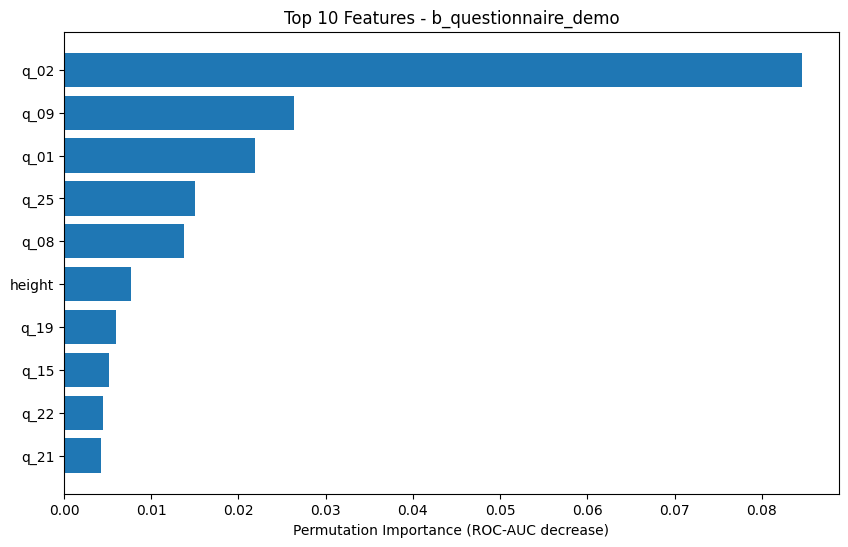


Top 5 features for b_questionnaire_demo:
  feature  importance_mean  importance_std
0    q_02         0.084615        0.027298
2    q_09         0.026387        0.017811
6    q_01         0.021865        0.017117
1    q_25         0.014965        0.016347
3    q_08         0.013706        0.013935


c:\Users\paolo\Desktop\Behavioral-Health-Informatic-Project\bhi-env\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\paolo\Desktop\Behavioral-Health-Informatic-Project\bhi-env\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\paolo\Desktop\Behavioral-Health-Informatic-Project\bhi-env\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl

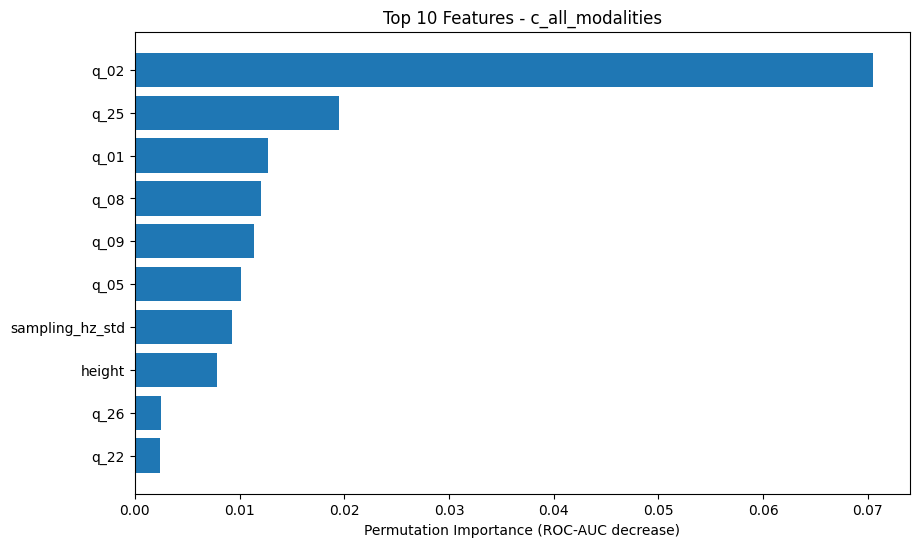


Top 5 features for c_all_modalities:
   feature  importance_mean  importance_std
0     q_02         0.070490        0.026566
2     q_25         0.019487        0.018707
3     q_01         0.012727        0.011607
1     q_08         0.012028        0.009705
10    q_09         0.011422        0.015323


In [6]:
# Permutation importance for feature interpretability
for setup, model in models.items():
    X_test = setups[setup]['X_test']
    perm_importance = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, random_state=42, scoring='roc_auc'
    )
    
    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': perm_importance.importances_mean,
        'importance_std': perm_importance.importances_std
    }).sort_values('importance_mean', ascending=False)
    
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(10)
    plt.barh(top_features['feature'], top_features['importance_mean'])
    plt.xlabel('Permutation Importance (ROC-AUC decrease)')
    plt.title(f'Top 10 Features - {setup}')
    plt.gca().invert_yaxis()
    plt.show()
    
    print(f"\nTop 5 features for {setup}:")
    print(importance_df.head(5))

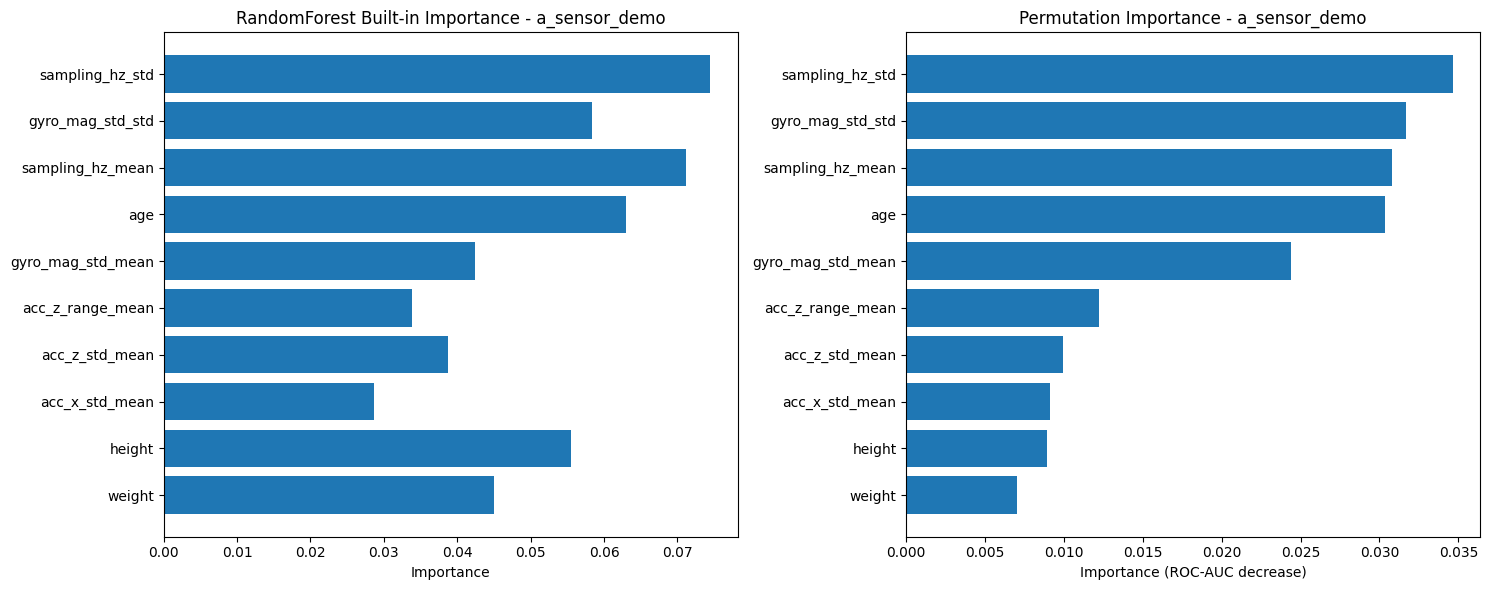


A_SENSOR_DEMO - Comparison of top 5 features:
             feature  rf_importance  permutation_importance
0    sampling_hz_std       0.074468                0.034639
4   gyro_mag_std_std       0.058301                0.031655
5   sampling_hz_mean       0.071163                0.030816
2                age       0.063013                0.030350
1  gyro_mag_std_mean       0.042462                0.024382
Correlation between RF importance and permutation importance: 0.739


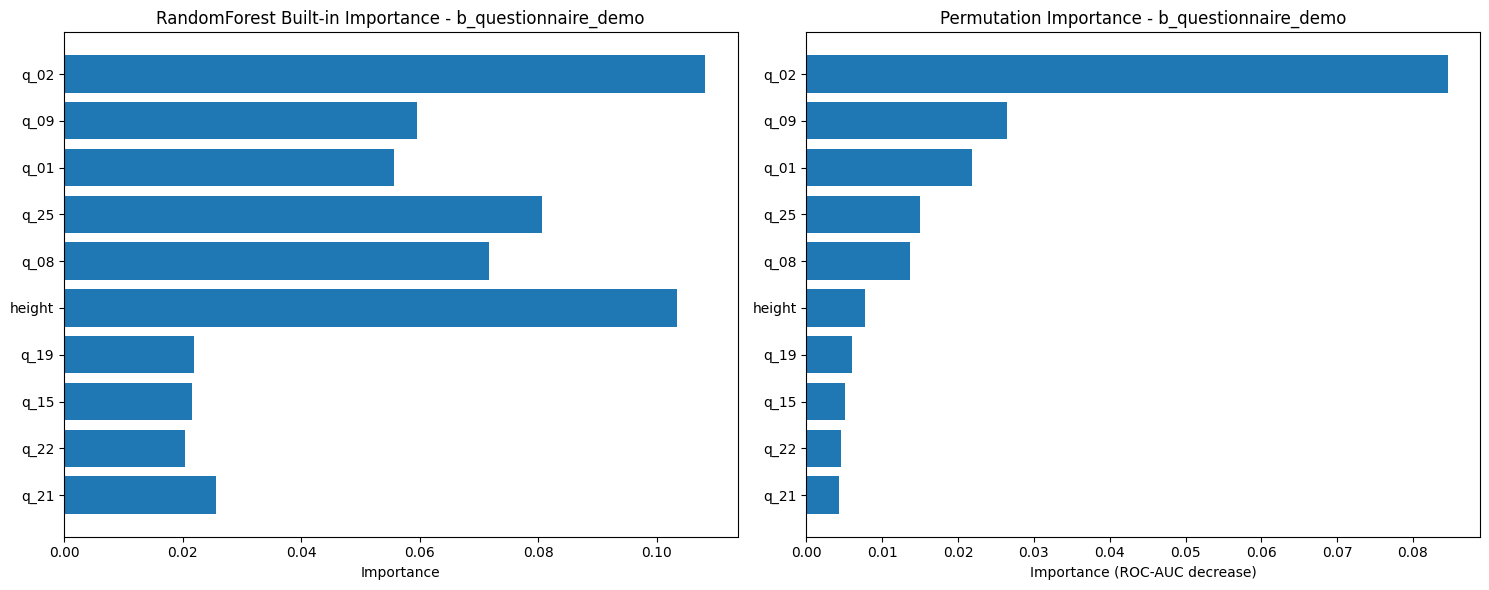


B_QUESTIONNAIRE_DEMO - Comparison of top 5 features:
  feature  rf_importance  permutation_importance
0    q_02       0.108213                0.084615
2    q_09       0.059492                0.026387
6    q_01       0.055635                0.021865
1    q_25       0.080652                0.014965
3    q_08       0.071761                0.013706
Correlation between RF importance and permutation importance: 0.516


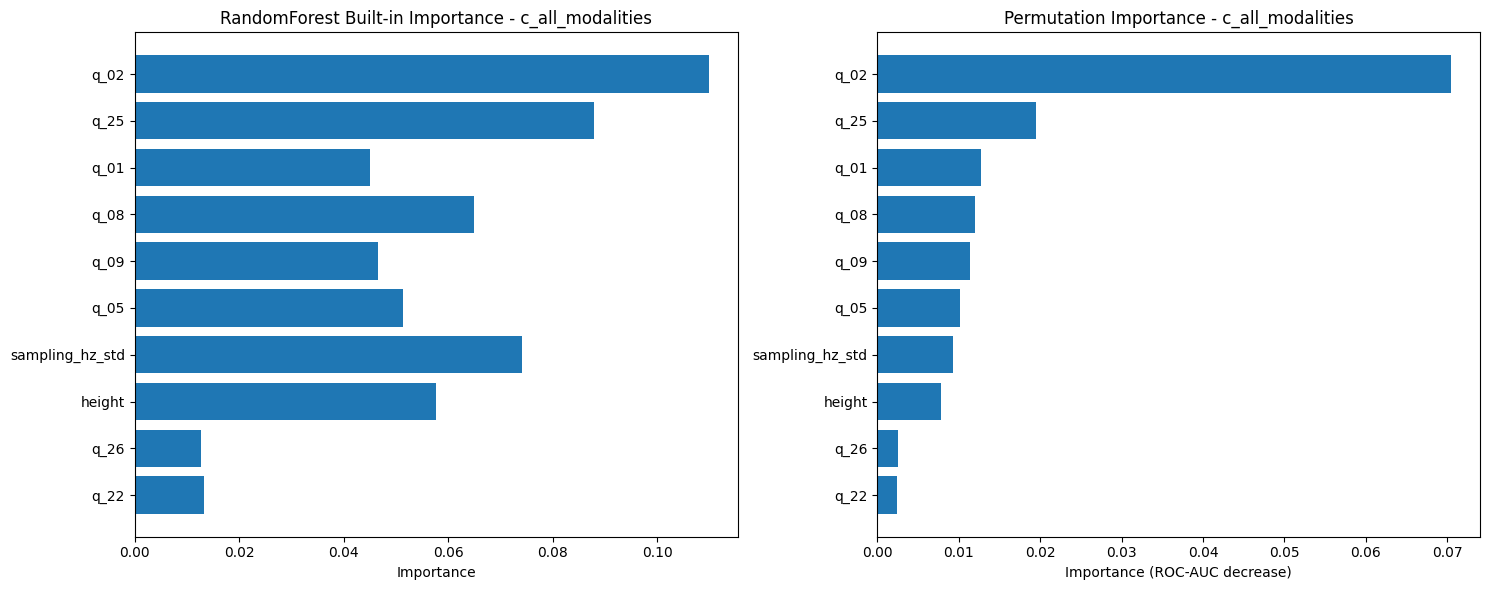


C_ALL_MODALITIES - Comparison of top 5 features:
   feature  rf_importance  permutation_importance
0     q_02       0.109907                0.070490
2     q_25       0.087837                0.019487
3     q_01       0.045037                0.012727
1     q_08       0.064916                0.012028
10    q_09       0.046497                0.011422
Correlation between RF importance and permutation importance: 0.660


In [7]:
# Compare built-in RandomForest importance vs Permutation importance
for setup, model in models.items():
    X_test = setups[setup]['X_test']
    
    # Built-in RandomForest feature importance (impurity-based)
    rf_importance = model.feature_importances_
    
    # Permutation importance (already calculated above)
    perm_importance_result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, random_state=42, scoring='roc_auc'
    )
    
    # Create comparison DataFrame
    comparison_df = pd.DataFrame({
        'feature': X_test.columns,
        'rf_importance': rf_importance,
        'permutation_importance': perm_importance_result.importances_mean
    }).sort_values('permutation_importance', ascending=False)
    
    # Plot comparison for top 10 features
    top_features = comparison_df.head(10)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # RandomForest importance
    ax1.barh(top_features['feature'], top_features['rf_importance'])
    ax1.set_title(f'RandomForest Built-in Importance - {setup}')
    ax1.set_xlabel('Importance')
    ax1.invert_yaxis()
    
    # Permutation importance
    ax2.barh(top_features['feature'], top_features['permutation_importance'])
    ax2.set_title(f'Permutation Importance - {setup}')
    ax2.set_xlabel('Importance (ROC-AUC decrease)')
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{setup.upper()} - Comparison of top 5 features:")
    print(comparison_df[['feature', 'rf_importance', 'permutation_importance']].head(5))
    
    # Calculate correlation between the two methods
    correlation = comparison_df['rf_importance'].corr(comparison_df['permutation_importance'])
    print(f"Correlation between RF importance and permutation importance: {correlation:.3f}")